In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


In [2]:
!pip install tensorflow


In [38]:
import os
print(os.listdir("./"))


['.ipynb_checkpoints', 'cnn.ipynb', 'test', 'train', 'validation']


In [39]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=(150, 150),
    batch_size=32
)


Found 256 files belonging to 2 classes.


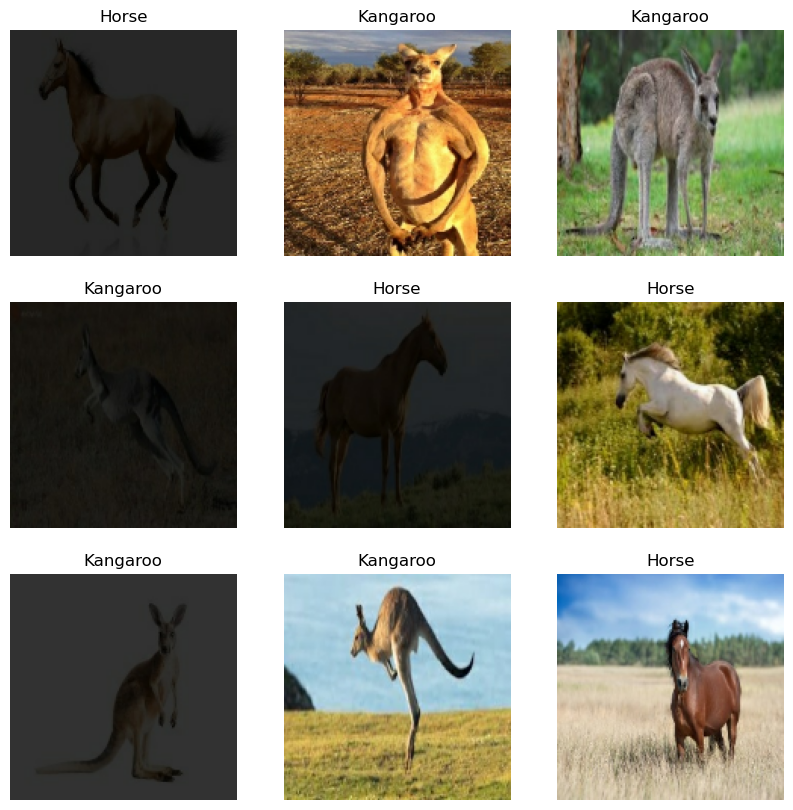

In [40]:
import matplotlib.pyplot as plt
class_names = train_ds.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [42]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


NameError: name 'val_ds' is not defined

In [43]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "validation",         
    image_size=(150, 150),
    batch_size=32
)


Found 256 files belonging to 2 classes.


In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define a simple CNN model
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),  # Adjust shape based on your image size
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 668ms/step - accuracy: 0.4863 - loss: 338.0811 - val_accuracy: 0.4961 - val_loss: 26.4148
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 623ms/step - accuracy: 0.5697 - loss: 18.1471 - val_accuracy: 0.7695 - val_loss: 1.1818
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 542ms/step - accuracy: 0.8422 - loss: 0.9993 - val_accuracy: 0.9688 - val_loss: 0.1329
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 545ms/step - accuracy: 0.9645 - loss: 0.1432 - val_accuracy: 0.9961 - val_loss: 0.0558
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 558ms/step - accuracy: 0.9936 - loss: 0.0419 - val_accuracy: 1.0000 - val_loss: 0.0115
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 540ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 527ms/step - accuracy: 0.9953 - loss: 0.0172 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 553ms/step - accuracy: 0.9981 - loss: 0.0052 - val_accuracy: 0.9883 - val_

In [45]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),  # Normalize pixel values
    layers.Conv2D(32, 3, activation='relu'),              # First Conv Layer
    layers.MaxPooling2D(),                                # First Pooling Layer
    layers.Conv2D(64, 3, activation='relu'),              # Second Conv Layer
    layers.MaxPooling2D(),                                # Second Pooling Layer
    layers.Conv2D(128, 3, activation='relu'),             # Third Conv Layer
    layers.MaxPooling2D(),                                # Third Pooling Layer
    layers.Flatten(),                                     # Flatten for Dense layers
    layers.Dense(128, activation='relu'),                 # Fully Connected Layer
    layers.Dense(1, activation='sigmoid')                 # Output Layer (binary class)
])


In [46]:
from tensorflow.keras import layers, models, Input

model = models.Sequential([
    Input(shape=(150, 150, 3)),                
    layers.Rescaling(1./255),                  
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')      
])


In [47]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5017 - loss: 0.9794 - val_accuracy: 0.5078 - val_loss: 0.6859
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 816ms/step - accuracy: 0.5226 - loss: 0.6888 - val_accuracy: 0.5234 - val_loss: 0.6543
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 809ms/step - accuracy: 0.6520 - loss: 0.6569 - val_accuracy: 0.7227 - val_loss: 0.6018
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 717ms/step - accuracy: 0.7118 - loss: 0.5977 - val_accuracy: 0.8711 - val_loss: 0.4734
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 793ms/step - accuracy: 0.8590 - loss: 0.4355 - val_accuracy: 0.8672 - val_loss: 0.3217
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 738ms/step - accuracy: 0.8203 - loss: 0.3531 - val_accuracy: 0.9180 - val_loss: 0.2526
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 740ms/step - accuracy: 0.9674 - loss: 0.1975 - val_accuracy: 0.9180 - val_loss: 0.1854
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 779ms/step - accuracy: 0.9390 - loss: 0.1568 - val_accuracy: 0.9805 - val_loss: 0

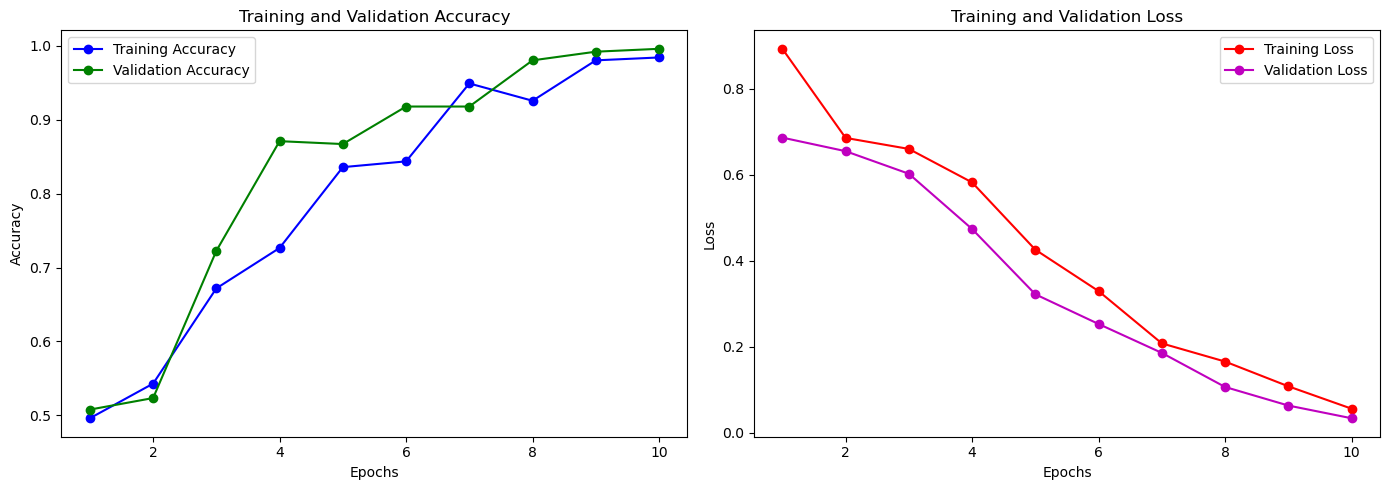

In [48]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'ro-', label='Training Loss')
plt.plot(epochs, val_loss, 'mo-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [49]:
img_path = 'test/Horse/Horse_2_2.jpg'  
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) 

predictions = model.predict(img_array)

if predictions[0] > 0.5:
    print("Predicted: Kangaroo")
else:
    print("Predicted: Horse")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
Predicted: Horse


In [50]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=(150, 150),
    batch_size=32
)


Found 256 files belonging to 2 classes.


In [51]:
import os

print(os.listdir("test/Horse"))


['Horse_1.jpeg', 'Horse_10.jpg', 'Horse_10_1.jpg', 'Horse_10_2.jpg', 'Horse_10_3.jpg', 'Horse_11.jpg', 'Horse_11_1.jpg', 'Horse_11_2.jpg', 'Horse_11_3.jpg', 'Horse_11_4.jpg', 'Horse_12.jpeg', 'Horse_12_1.jpg', 'Horse_12_2.jpg', 'Horse_12_3.jpg', 'Horse_12_4.jpg', 'Horse_13.jpeg', 'Horse_13_1.jpg', 'Horse_13_2.jpg', 'Horse_13_3.jpg', 'Horse_14.jpeg', 'Horse_14_1.jpg', 'Horse_14_2.jpg', 'Horse_14_3.jpg', 'Horse_15.jpg', 'Horse_15_1.jpg', 'Horse_15_2.jpg', 'Horse_15_3.jpg', 'Horse_15_4.jpg', 'Horse_16.jpeg', 'Horse_16_1.jpg', 'Horse_16_2.jpg', 'Horse_16_3.jpg', 'Horse_17.jpeg', 'Horse_17_1.jpg', 'Horse_17_2.jpg', 'Horse_17_3.jpg', 'Horse_18.jpeg', 'Horse_18_1.jpg', 'Horse_18_2.jpg', 'Horse_18_3.jpg', 'Horse_18_4.jpg', 'Horse_19.jpeg', 'Horse_19_1.jpg', 'Horse_19_2.jpg', 'Horse_19_3.jpg', 'Horse_1_1.jpg', 'Horse_1_2.jpg', 'Horse_1_3.jpg', 'Horse_1_4.jpg', 'Horse_2.jpeg', 'Horse_20.jpeg', 'Horse_20_1.jpg', 'Horse_20_2.jpg', 'Horse_20_3.jpg', 'Horse_20_4.jpg', 'Horse_21.jpeg', 'Horse_21_1.jp

In [52]:
img_path = 'test/Horse/Horse_1_1.jpg'  # <- replace with actual filename you found


In [53]:
img_path = 'test/Horse/Horse_1_1.jpg'  # update this
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  

predictions = model.predict(img_array)

class_names = train_ds.class_names
predicted_class = class_names[int(predictions[0] > 0.5)]
print(f"Predicted class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Predicted class: Horse


C:\Users\karod_gkkb7db\AppData\Local\Temp\ipykernel_25748\4153545051.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = class_names[int(predictions[0] > 0.5)]


In [54]:
prediction = predictions[0][0]         
predicted_class = class_names[int(prediction > 0.5)]
print(f"Predicted class: {predicted_class}")


Predicted class: Horse


In [18]:
!pip install ipywidgets


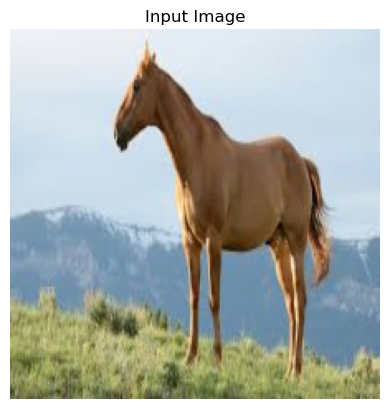

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
🎯 Predicted Class: Horse
📊 Confidence: 1.98%


In [55]:
import os
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ✅ Set path to your test image 
img_path = 'test/Horse/Horse_1_1.jpg'  


img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.title("Input Image")
plt.show()


img = img.resize((150, 150))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # shape: (1, 150, 150, 3)


predictions = model.predict(img_array)
prob = predictions[0][0]  # extract scalar value
class_names = train_ds.class_names  # e.g. ['Horse', 'Kangaroo']
predicted_class = class_names[int(prob > 0.5)]


print(f"🎯 Predicted Class: {predicted_class}")
print(f"📊 Confidence: {prob*100:.2f}%")


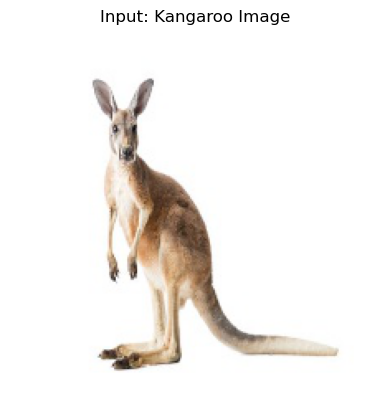

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
🎯 Predicted Class: Kangaroo
📊 Confidence: 99.97%


In [56]:
import os
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


img_path = 'test/Kangaroo/Kangaroo_1_1.jpg'  # Change to your file

img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.title("Input: Kangaroo Image")
plt.show()

img = img.resize((150, 150))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Shape: (1, 150, 150, 3)


predictions = model.predict(img_array)
prob = predictions[0][0]   
class_names = train_ds.class_names  # ['Horse', 'Kangaroo']
predicted_class = class_names[int(prob > 0.5)]


print(f"🎯 Predicted Class: {predicted_class}")
print(f"📊 Confidence: {prob * 100:.2f}%")


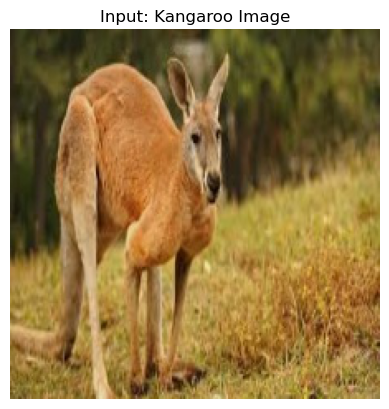

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
🎯 Predicted Class: Kangaroo
📊 Confidence: 99.92%


In [57]:
import os
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ✅ Path to one Kangaroo image (update filename as per your dataset)
img_path = 'test/Kangaroo/Kangaroo_11_1.jpg'  # Change to your file

# ✅ Load and show the image
img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.title("Input: Kangaroo Image")
plt.show()

# ✅ Preprocess the image
img = img.resize((150, 150))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Shape: (1, 150, 150, 3)

# ✅ Predict
predictions = model.predict(img_array)
prob = predictions[0][0]  # Extract scalar
class_names = train_ds.class_names  # ['Horse', 'Kangaroo']
predicted_class = class_names[int(prob > 0.5)]

# ✅ Output the result
print(f"🎯 Predicted Class: {predicted_class}")
print(f"📊 Confidence: {prob * 100:.2f}%")
